<h2> <strong> <span style="color: lightgreen"> Polars vs Pandas 🐼
</span>
</strong>
</h2>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive



- **Linkedin Jobs and Skills:**
  - Pata comparar el rendimiento de las paqueterias Pandas y Polars se utiliza el data set de empleos de Linkedin que tiene una dimensión de 1,348,454  filas y 14 columnas.
  - Sitio web: [Kaggle]( https://www.kaggle.com/datasets/asaniczka/1-3m-linkedin-jobs-and-skills-2024)







* <h3> <strong> <span style="color: darkgreen"> Carga de datos CSV
</strong>
</h4>

In [2]:
import polars as pl
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#Reading
path_data_link = fr'/content/drive/MyDrive/cursos-para-dictar/UDM/05_clase/linkedin_job_postings.csv'

In [3]:
%%time
df_pd_read = pd.read_csv(path_data_link) # pandas

CPU times: user 9.8 s, sys: 1.59 s, total: 11.4 s
Wall time: 16.2 s


In [4]:
%%time
df_pl_read = pl.read_csv(path_data_link) # polars

CPU times: user 2.63 s, sys: 998 ms, total: 3.63 s
Wall time: 4.51 s


* `-n10` : se repite la ejecución 10 veces por cada ciclo

* `-r1` : ejecuta 1 ciclo en total

* `-o` : guarda el resultado de la medición en una variable

In [5]:
pl_time_read_csv = %timeit -o -n10 -r1 pl.read_csv(path_data_link)

2.46 s ± 0 ns per loop (mean ± std. dev. of 1 run, 10 loops each)


In [6]:
pd_time_read_csv = %timeit -o -n10 -r1 pd.read_csv(path_data_link)

11.1 s ± 0 ns per loop (mean ± std. dev. of 1 run, 10 loops each)


Con pandas, aproximadamente cada ejecución tardó 10 segundos. Por su parte, con polars tardó 2.16 segundos.

In [7]:
df_pl_read.head(2)

job_link,last_processed_time,got_summary,got_ner,is_being_worked,job_title,company,job_location,first_seen,search_city,search_country,search_position,job_level,job_type
str,str,str,str,str,str,str,str,str,str,str,str,str,str
"""https://www.linkedin.com/jobs/…","""2024-01-21 07:12:29.00256+00""","""t""","""t""","""f""","""Account Executive - Dispensing…","""BD""","""San Diego, CA""","""2024-01-15""","""Coronado""","""United States""","""Color Maker""","""Mid senior""","""Onsite"""
"""https://www.linkedin.com/jobs/…","""2024-01-21 07:39:58.88137+00""","""t""","""t""","""f""","""Registered Nurse - RN Care Man…","""Trinity Health MI""","""Norton Shores, MI""","""2024-01-14""","""Grand Haven""","""United States""","""Director Nursing Service""","""Mid senior""","""Onsite"""


In [8]:
df_pd_read.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1348454 entries, 0 to 1348453
Data columns (total 14 columns):
 #   Column               Non-Null Count    Dtype 
---  ------               --------------    ----- 
 0   job_link             1348454 non-null  object
 1   last_processed_time  1348454 non-null  object
 2   got_summary          1348454 non-null  object
 3   got_ner              1348454 non-null  object
 4   is_being_worked      1348454 non-null  object
 5   job_title            1348454 non-null  object
 6   company              1348443 non-null  object
 7   job_location         1348435 non-null  object
 8   first_seen           1348454 non-null  object
 9   search_city          1348454 non-null  object
 10  search_country       1348454 non-null  object
 11  search_position      1348454 non-null  object
 12  job_level            1348454 non-null  object
 13  job_type             1348454 non-null  object
dtypes: object(14)
memory usage: 144.0+ MB


In [9]:
print(df_pl_read.columns)

['job_link', 'last_processed_time', 'got_summary', 'got_ner', 'is_being_worked', 'job_title', 'company', 'job_location', 'first_seen', 'search_city', 'search_country', 'search_position', 'job_level', 'job_type']


In [10]:
# Función para graficar

def bar_plot(pl_time, pd_time):
    data = {'Library': ['Polars', 'Pandas'],
            'Average Time (seconds)': [pl_time, pd_time]}
    df = pd.DataFrame(data)
    plt.figure(figsize=(8, 6))
    custom_palette = ["royalblue", "darkgrey"]
    sns.set(style="whitegrid")
    ax = sns.barplot(x='Library', y='Average Time (seconds)', data=df, palette= custom_palette)
    ax.set_title('Tiempo promedio de ejecución')
    ax.set_xlabel('Librería')
    ax.set_ylabel('Tiempo promedio (segundos)')

    # Annotate bars with values
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', fontsize=12, color='black', xytext=(0, 5),
                    textcoords='offset points')

    plt.show()

<ipython-input-10-f745cac09d91>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Library', y='Average Time (seconds)', data=df, palette= custom_palette)


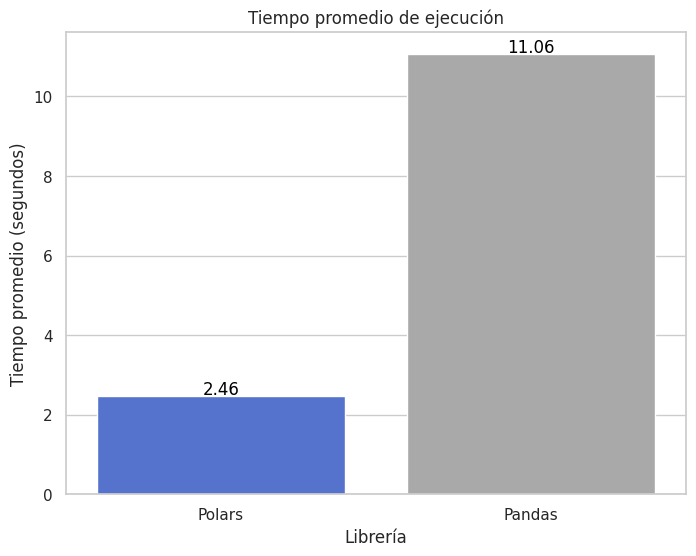

In [11]:
bar_plot(pl_time_read_csv.average, pd_time_read_csv.average)